In [5]:

# PINN model============================================================

import torch
import torch.nn as nn
import numpy as np


# ─── Fourier Feature Embedding ────────────────────────────────────────────────
class FourierEmbedding(nn.Module):
    def __init__(self, input_dim=4, embed_dim=64, scale=2.0):
        super().__init__()
        B = torch.randn(input_dim, embed_dim // 2) * scale
        self.register_buffer("B", B)

    def forward(self, x):
        proj = 2 * np.pi * x @ self.B
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)


# ─── Residual Block ───────────────────────────────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.fc1  = nn.Linear(width, width)
        self.fc2  = nn.Linear(width, width)
        self.act  = nn.Tanh()
        self.norm = nn.LayerNorm(width)

    def forward(self, x):
        h = self.act(self.fc1(x))
        h = self.fc2(h)
        return self.norm(x + h)


# ─── PINN Network ─────────────────────────────────────────────────────────────
class PCM_PINN(nn.Module):
    """
    Input:  [x_n, y_n, t_n, T_hot_n]  — all normalized to [0,1]
    Output: [T_n, lf, ux_n, uy_n]
    """
    def __init__(self, hidden_dim=128, n_layers=6, embed_dim=64, fourier_scale=2.0):
        super().__init__()
        self.fourier    = FourierEmbedding(4, embed_dim, fourier_scale)
        self.input_proj = nn.Sequential(nn.Linear(embed_dim, hidden_dim), nn.Tanh())
        self.res_blocks = nn.ModuleList([ResidualBlock(hidden_dim) for _ in range(n_layers)])

        # Output heads
        self.head_T  = nn.Sequential(nn.Linear(hidden_dim, 32), nn.Tanh(),
                                      nn.Linear(32, 1))
        self.head_lf = nn.Sequential(nn.Linear(hidden_dim, 32), nn.Tanh(),
                                      nn.Linear(32, 1), nn.Sigmoid())  # lf ∈ [0,1]
        self.head_u  = nn.Sequential(nn.Linear(hidden_dim, 32), nn.Tanh(),
                                      nn.Linear(32, 2))

    def forward(self, x):
        emb = self.fourier(x)
        h   = self.input_proj(emb)
        for blk in self.res_blocks:
            h = blk(h)
        T_n  = self.head_T(h)
        lf   = self.head_lf(h)
        uv   = self.head_u(h)
        return torch.cat([T_n, lf, uv[:, 0:1], uv[:, 1:2]], dim=1)


# ─── Physics Loss ─────────────────────────────────────────────────────────────
class PhysicsLoss(nn.Module):
    def __init__(self, phys_params):
        super().__init__()
        p = phys_params
        # Register all physical constants as buffers (float → tensor)
        self.register_buffer("rho",     torch.tensor(float(p["rho"]),     dtype=torch.float32))
        self.register_buffer("cp",      torch.tensor(float(p["cp"]),      dtype=torch.float32))
        self.register_buffer("k_s",     torch.tensor(float(p["k_s"]),     dtype=torch.float32))
        self.register_buffer("k_l",     torch.tensor(float(p["k_l"]),     dtype=torch.float32))
        self.register_buffer("mu",      torch.tensor(float(p["mu"]),      dtype=torch.float32))
        self.register_buffer("beta",    torch.tensor(float(p["beta"]),    dtype=torch.float32))
        self.register_buffer("L_lat",   torch.tensor(float(p["L_lat"]),   dtype=torch.float32))
        self.register_buffer("T_melt",  torch.tensor(float(p["T_melt"]),  dtype=torch.float32))
        self.register_buffer("T_cold",  torch.tensor(float(p["T_cold"]),  dtype=torch.float32))
        self.register_buffer("T_scale", torch.tensor(float(p["T_scale"]), dtype=torch.float32))
        self.register_buffer("u_scale", torch.tensor(float(p["u_scale"]), dtype=torch.float32))
        self.register_buffer("W",       torch.tensor(float(p["W"]),       dtype=torch.float32))
        self.register_buffer("H_dom",   torch.tensor(float(p["H_dom"]),   dtype=torch.float32))
        self.register_buffer("t_end",   torch.tensor(float(p["t_end"]),   dtype=torch.float32))
        self.register_buffer("A_mush",  torch.tensor(float(p["A_mush"]),  dtype=torch.float32))
        self.register_buffer("g",       torch.tensor(float(p["g"]),       dtype=torch.float32))
        # These are plain Python floats — NOT buffers
        self.dT_mush = float(1.0 / p["T_scale"])   # normalized mushy zone width
        self.eps_ck  = float(p["eps_ck"])           # Carman-Kozeny epsilon

    def compute_residuals(self, model, X_coll):
        """
        X_coll: [N, 4] collocation points, requires_grad will be set here.
        Returns dict of residual tensors (squared mean = loss for each).
        """
        X = X_coll.clone().requires_grad_(True)
        pred = model(X)   # [N, 4]: T_n, lf, ux_n, uy_n

        T_n  = pred[:, 0:1]
        lf   = pred[:, 1:2]
        ux_n = pred[:, 2:3]
        uy_n = pred[:, 3:4]

        ones = torch.ones_like(T_n)

        # ── Autograd gradients ────────────────────────────────────────────────
        def D(out, inp):
            return torch.autograd.grad(out, inp,
                                       grad_outputs=torch.ones_like(out),
                                       create_graph=True,
                                       retain_graph=True)[0]

        dT  = D(T_n,  X)   # [N, 4]: ∂T_n/∂(x_n, y_n, t_n, thot_n)
        dlf = D(lf,   X)
        dux = D(ux_n, X)
        duy = D(uy_n, X)

        # Unpack spatial/time derivatives
        dT_dxn  = dT[:, 0:1];  dT_dyn  = dT[:, 1:2];  dT_dtn  = dT[:, 2:3]
        dlf_dtn = dlf[:, 2:3]
        dux_dxn = dux[:, 0:1]; dux_dyn = dux[:, 1:2]; dux_dtn = dux[:, 2:3]
        duy_dxn = duy[:, 0:1]; duy_dyn = duy[:, 1:2]; duy_dtn = duy[:, 2:3]

        # ── Second derivatives (for diffusion/viscosity terms) ────────────────
        d2T_dx2 = D(dT_dxn, X)[:, 0:1]
        d2T_dy2 = D(dT_dyn, X)[:, 1:2]
        d2ux_dx2= D(dux_dxn, X)[:, 0:1]
        d2ux_dy2= D(dux_dyn, X)[:, 1:2]
        d2uy_dx2= D(duy_dxn, X)[:, 0:1]
        d2uy_dy2= D(duy_dyn, X)[:, 1:2]

        # ── Convert normalized → physical units ───────────────────────────────
        W  = self.W;    H  = self.H_dom;  te = self.t_end
        Ts = self.T_scale;  us = self.u_scale

        dT_dx = dT_dxn * Ts / W;       dT_dy  = dT_dyn * Ts / H
        dT_dt = dT_dtn * Ts / te
        dlf_dt= dlf_dtn / te
        d2T   = d2T_dx2 * Ts/W**2 + d2T_dy2 * Ts/H**2

        dux_dx= dux_dxn * us / W;      dux_dy = dux_dyn * us / H
        dux_dt= dux_dtn * us / te
        duy_dx= duy_dxn * us / W;      duy_dy = duy_dyn * us / H
        duy_dt= duy_dtn * us / te
        d2ux  = d2ux_dx2 * us/W**2 + d2ux_dy2 * us/H**2
        d2uy  = d2uy_dx2 * us/W**2 + d2uy_dy2 * us/H**2

        ux_p  = ux_n * us
        uy_p  = uy_n * us
        T_phys= T_n  * Ts + self.T_cold

        # ── Effective conductivity ────────────────────────────────────────────
        k_eff = self.k_s + (self.k_l - self.k_s) * lf

        # ── Carman-Kozeny drag ────────────────────────────────────────────────
        S_ck  = self.A_mush * (1 - lf)**2 / (lf**3 + self.eps_ck)

        # ── 1. Energy equation ────────────────────────────────────────────────
        # ρ cp ∂T/∂t + ρ L ∂lf/∂t + ρ cp (u·∇T) = k_eff ∇²T
        res_energy = (self.rho * self.cp * dT_dt
                      + self.rho * self.L_lat * dlf_dt
                      + self.rho * self.cp * (ux_p * dT_dx + uy_p * dT_dy)
                      - k_eff * d2T)

        # ── 2. Liquid fraction consistency ────────────────────────────────────
        # lf should equal tanh regularization of T
        T_melt_n = (self.T_melt - self.T_cold) / self.T_scale
        lf_from_T = 0.5 * (1.0 + torch.tanh((T_n - T_melt_n) / self.dT_mush))
        res_lf    = lf - lf_from_T

        # ── 3. Continuity (incompressibility) ─────────────────────────────────
        res_cont = dux_dx + duy_dy

        # ── 4. x-momentum ─────────────────────────────────────────────────────
        res_mom_x = (self.rho * dux_dt
                     + self.rho * (ux_p * dux_dx + uy_p * dux_dy)
                     - self.mu  * d2ux
                     + S_ck * ux_p)

        # ── 5. y-momentum (Boussinesq buoyancy) ───────────────────────────────
        buoyancy  = self.rho * self.beta * self.g * (T_phys - self.T_cold)
        res_mom_y = (self.rho * duy_dt
                     + self.rho * (ux_p * duy_dx + uy_p * duy_dy)
                     - self.mu  * d2uy
                     - buoyancy
                     + S_ck * uy_p)

        return {
            "energy":  res_energy,
            "lf_cons": res_lf,
            "cont":    res_cont,
            "mom_x":   res_mom_x,
            "mom_y":   res_mom_y,
        }


# ─── Convenience constructor ──────────────────────────────────────────────────
def build_model(hidden_dim=128, n_layers=6, embed_dim=64):
    return PCM_PINN(hidden_dim=hidden_dim, n_layers=n_layers, embed_dim=embed_dim)


# ─── Quick sanity check (runs when you execute this cell) ────────────────────
if __name__ == "__main__" or True:
    _model = build_model()
    _x     = torch.rand(16, 4)
    _out   = _model(_x)
    print(f"Output shape: {_out.shape}")
    print(f"lf range in output: {_out[:,1].min():.3f} – {_out[:,1].max():.3f}")
    n_params = sum(p.numel() for p in _model.parameters())
    print(f"Trainable parameters: {n_params:,}")
    print("File 3 OK — ready for File 4")

Output shape: torch.Size([16, 4])
lf range in output: 0.395 – 0.658
Trainable parameters: 220,516
File 3 OK — ready for File 4


Device: cpu
Dataset: 8 cases, 40 timesteps, 25x25 grid
Points per case: 25,000
Normalization: T_scale=55.0K  u_max=0.009439m/s

Split (NO leakage):
  Train cases [0, 2, 4, 6]: 100,000 pts
  Val   cases [1, 5]:   50,000 pts
  Test  cases [3, 7]:  50,000 pts

Output statistics:
  T_n: mean=0.2078  std=0.1504  min=-0.0182  max=0.9273
  lf: mean=0.5702  std=0.3864  min=0.0000  max=1.0000
  ux_n: mean=-0.0016  std=0.0448  min=-0.4913  max=0.4768
  uy_n: mean=-0.0008  std=0.0462  min=-0.4351  max=0.7154

Model parameters: 331,268

Training with correct case-based split

E0010 | Train:0.00181 | Val:0.01294 | LR:5.0e-04 ✅
E0020 | Train:0.03296 | Val:0.02911 | LR:4.9e-04
E0030 | Train:0.01150 | Val:0.01442 | LR:4.9e-04
E0040 | Train:0.00974 | Val:0.01361 | LR:4.8e-04
E0050 | Train:0.00918 | Val:0.01362 | LR:4.7e-04
        T:0.01663 | lf:0.03457 | ux:0.00176 | uy:0.00150
E0060 | Train:0.00898 | Val:0.01323 | LR:4.5e-04
E0070 | Train:0.00878 | Val:0.01387 | LR:4.4e-04
E0080 | Train:0.00885 | Val

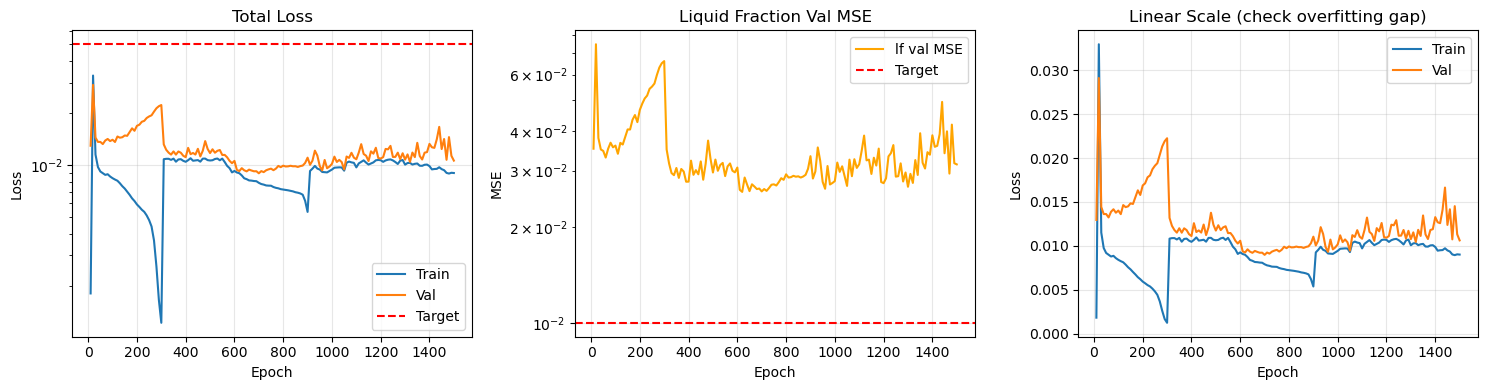

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([scalar])` or the `torch.serialization.safe_globals([scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weigh

In [2]:

#training loop
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import h5py

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ─── Step 1: Load raw data from HDF5 ─────────────────────────────────────────
data_path = r"C:\Users\raksh\pcm_2d_dataset.h5"
with h5py.File(data_path, "r") as f:
    temperature     = f["T"][:]       # (8, 40, 25, 25)
    liquid_fraction = f["lf"][:]
    velocity_x      = f["ux"][:]
    velocity_y      = f["uy"][:]
    time_points     = f["t"][:]
    x_coords        = f["x"][:]
    y_coords        = f["y"][:]
    params          = f["params"][:]
    W = float(f.attrs["W"])
    H = float(f.attrs["H"])

N_cases, Nt, Ny, Nx = temperature.shape
t_end    = float(time_points[-1])
T_hot_min = float(params[:,0].min())
T_hot_max = float(params[:,0].max())
T_cold    = float(params[0,1])

print(f"Dataset: {N_cases} cases, {Nt} timesteps, {Ny}x{Nx} grid")

# ─── Step 2: Build dataset per case (VECTORIZED) ──────────────────────────────
# Normalize inputs to [0,1]
x_n = x_coords / W                          # (Nx,)
y_n = y_coords / H                          # (Ny,)
t_n = time_points / t_end                   # (Nt,)

# Normalize outputs
T_scale  = T_hot_max - T_cold
u_max    = max(abs(velocity_x).max(), abs(velocity_y).max(), 1e-8) * 1.25

# Build meshgrid
t_grid, y_grid, x_grid = np.meshgrid(t_n, y_n, x_n, indexing='ij')  # (Nt,Ny,Nx)

case_X = {}   # case_idx → input array (pts_per_case, 4)
case_Y = {}   # case_idx → output array (pts_per_case, 4)

for c in range(N_cases):
    thot_n = (params[c,0] - T_hot_min) / (T_hot_max - T_hot_min + 1e-8)
    thot_grid = np.full((Nt, Ny, Nx), thot_n, dtype=np.float32)

    inp = np.stack([x_grid.ravel(), y_grid.ravel(),
                    t_grid.ravel(), thot_grid.ravel()], axis=1).astype(np.float32)

    T_n  = ((temperature[c]     - T_cold) / T_scale).ravel().astype(np.float32)
    lf_n = liquid_fraction[c].ravel().astype(np.float32)
    ux_n = np.clip(velocity_x[c], -u_max, u_max).ravel().astype(np.float32) / u_max
    uy_n = np.clip(velocity_y[c], -u_max, u_max).ravel().astype(np.float32) / u_max

    out = np.stack([T_n, lf_n, ux_n, uy_n], axis=1)

    case_X[c] = inp
    case_Y[c] = out

pts_per_case = Nt * Ny * Nx
print(f"Points per case: {pts_per_case:,}")
print(f"Normalization: T_scale={T_scale:.1f}K  u_max={u_max:.6f}m/s")

# ─── Step 3: Case-based split (NO data leakage) ───────────────────────────────
# Train on every other case so val cases always interpolate
train_cases = [0, 2, 4, 6]   # 45,55,65,75C
val_cases   = [1, 5]          # 50,70C  ← interpolation between train cases
test_cases  = [3, 7]          # 60,80C

X_train = np.concatenate([case_X[c] for c in train_cases])
Y_train = np.concatenate([case_Y[c] for c in train_cases])
X_val   = np.concatenate([case_X[c] for c in val_cases])
Y_val   = np.concatenate([case_Y[c] for c in val_cases])
X_test  = np.concatenate([case_X[c] for c in test_cases])
Y_test  = np.concatenate([case_Y[c] for c in test_cases])

print(f"\nSplit (NO leakage):")
print(f"  Train cases {train_cases}: {len(X_train):,} pts")
print(f"  Val   cases {val_cases}:   {len(X_val):,} pts")
print(f"  Test  cases {test_cases}:  {len(X_test):,} pts")

# Output stats after correct normalization
print(f"\nOutput statistics:")
for i, name in enumerate(["T_n","lf","ux_n","uy_n"]):
    print(f"  {name}: mean={Y_train[:,i].mean():.4f}  "
          f"std={Y_train[:,i].std():.4f}  "
          f"min={Y_train[:,i].min():.4f}  "
          f"max={Y_train[:,i].max():.4f}")

# ─── Step 4: DataLoaders ──────────────────────────────────────────────────────
def to_t(arr):
    return torch.from_numpy(arr).float().to(device)

BATCH = 4096

train_dl = DataLoader(TensorDataset(to_t(X_train), to_t(Y_train)),
                      batch_size=BATCH, shuffle=True)
val_dl   = DataLoader(TensorDataset(to_t(X_val),   to_t(Y_val)),
                      batch_size=BATCH, shuffle=False)

# ─── Step 5: SIREN model (keep your architecture) ────────────────────────────
class SineLayer(nn.Module):
    def __init__(self, in_f, out_f, is_first=False, omega=30.0):
        super().__init__()
        self.omega = omega
        self.linear = nn.Linear(in_f, out_f)
        # SIREN initialization
        with torch.no_grad():
            if is_first:
                self.linear.weight.uniform_(-1/in_f, 1/in_f)
            else:
                bound = np.sqrt(6/in_f) / omega
                self.linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega * self.linear(x))


class PCM_SIREN(nn.Module):
    def __init__(self, in_dim=4, hidden=256, n_layers=6, out_dim=4):
        super().__init__()
        layers = [SineLayer(in_dim, hidden, is_first=True)]
        for _ in range(n_layers - 1):
            layers.append(SineLayer(hidden, hidden))
        self.net    = nn.Sequential(*layers)
        self.head_T  = nn.Linear(hidden, 1)              # T_n  (linear)
        self.head_lf = nn.Sequential(nn.Linear(hidden,1), nn.Sigmoid())  # lf ∈[0,1]
        self.head_u  = nn.Linear(hidden, 2)              # ux_n, uy_n

    def forward(self, x):
        h = self.net(x)
        T_n  = self.head_T(h)
        lf   = self.head_lf(h)
        uv   = self.head_u(h)
        return torch.cat([T_n, lf, uv[:,0:1], uv[:,1:2]], dim=1)


# ─── Step 6: Training ─────────────────────────────────────────────────────────
def train_model(n_epochs=1500):
    model = PCM_SIREN(hidden=256, n_layers=6).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nModel parameters: {n_params:,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4,
                                  weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=300, T_mult=2, eta_min=1e-5
    )

    best_val  = float("inf")
    patience  = 0
    history   = {"train": [], "val": [], "lf_val": []}

    print(f"\n{'='*65}")
    print("Training with correct case-based split")
    print(f"{'='*65}\n")

    for epoch in range(1, n_epochs + 1):
        # Training
        model.train()
        train_loss = 0.0
        for X_b, Y_b in train_dl:
            optimizer.zero_grad()
            pred = model(X_b)
            loss = F.mse_loss(pred, Y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_dl)
        scheduler.step()

        # Validation every 10 epochs
        if epoch % 10 == 0:
            model.eval()
            val_loss = 0.0
            per_out  = torch.zeros(4)
            with torch.no_grad():
                for X_b, Y_b in val_dl:
                    pred      = model(X_b)
                    val_loss += F.mse_loss(pred, Y_b).item()
                    for i in range(4):
                        per_out[i] += F.mse_loss(pred[:,i].cpu(),
                                                  Y_b[:,i].cpu()).item()
            val_loss /= len(val_dl)
            per_out  /= len(val_dl)

            history["train"].append(train_loss)
            history["val"].append(val_loss)
            history["lf_val"].append(per_out[1].item())

            lr = optimizer.param_groups[0]["lr"]
            print(f"E{epoch:04d} | Train:{train_loss:.5f} | "
                  f"Val:{val_loss:.5f} | LR:{lr:.1e}", end="")

            if epoch % 50 == 0:
                print()
                print(f"        T:{per_out[0]:.5f} | lf:{per_out[1]:.5f} | "
                      f"ux:{per_out[2]:.5f} | uy:{per_out[3]:.5f}")

            if val_loss < best_val:
                best_val = val_loss
                patience = 0
                torch.save({
                    "model_state": model.state_dict(),
                    "epoch": epoch,
                    "val_loss": best_val,
                    "T_scale": T_scale,
                    "u_max": u_max,
                    "T_cold": T_cold,
                    "T_hot_min": T_hot_min,
                    "T_hot_max": T_hot_max,
                }, "best_model_corrected.pt")
                print(" ✅")
            else:
                patience += 1
                if epoch % 50 != 0:
                    print()

            if patience >= 150:
                print(f"\nEarly stopping at epoch {epoch}")
                break

    print(f"\nBest val loss: {best_val:.5f}")

    # Loss curves
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ep = list(range(10, len(history["val"])*10+1, 10))

    axes[0].semilogy(ep, history["train"], label="Train")
    axes[0].semilogy(ep, history["val"],   label="Val")
    axes[0].axhline(0.05, color="red", ls="--", label="Target")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Total Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].semilogy(ep, history["lf_val"], color="orange", label="lf val MSE")
    axes[1].axhline(0.01, color="red", ls="--", label="Target")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MSE")
    axes[1].set_title("Liquid Fraction Val MSE")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(ep, history["train"], label="Train")
    axes[2].plot(ep, history["val"],   label="Val")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Loss")
    axes[2].set_title("Linear Scale (check overfitting gap)")
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_corrected.png", dpi=150, bbox_inches="tight")
    plt.show()

    return model, best_val

model, best_val = train_model(n_epochs=1500)

# ─── Step 7: Final evaluation ─────────────────────────────────────────────────
ckpt = torch.load("best_model_corrected.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

X_test_t = to_t(X_test)
Y_test_t = to_t(Y_test)

with torch.no_grad():
    pred_test = model(X_test_t)

print(f"\n=== Test set evaluation (cases {test_cases}) ===")
for i, name in enumerate(["T_n","lf","ux_n","uy_n"]):
    mse  = ((pred_test[:,i] - Y_test_t[:,i])**2).mean().item()
    # Convert back to physical units
    if name == "T_n":
        rmse_phys = np.sqrt(mse) * T_scale
        print(f"  {name}: MSE={mse:.5f}  RMSE={rmse_phys:.3f} K")
    elif name == "lf":
        print(f"  {name}: MSE={mse:.5f}  RMSE={np.sqrt(mse):.4f} (dimensionless)")
    else:
        rmse_phys = np.sqrt(mse) * u_max
        print(f"  {name}: MSE={mse:.5f}  RMSE={rmse_phys:.6f} m/s")

In [4]:
import torch
import numpy as np

ckpt = torch.load("best_model_corrected.pt", map_location=device,weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()

T_scale  = ckpt["T_scale"]
u_max    = ckpt["u_max"]

X_test_t = to_t(X_test)
Y_test_t = to_t(Y_test)

with torch.no_grad():
    pred = model(X_test_t)

print("=== Physical Unit Errors (Test Set) ===")
names  = ["T",   "lf",   "ux",   "uy"]
scales = [T_scale, 1.0, u_max, u_max]
units  = ["K",  "—",  "m/s",  "m/s"]

for i, (name, scale, unit) in enumerate(zip(names, scales, units)):
    mse  = ((pred[:,i] - Y_test_t[:,i])**2).mean().item()
    rmse = np.sqrt(mse) * scale
    mae  = (pred[:,i] - Y_test_t[:,i]).abs().mean().item() * scale
    # R² score
    ss_res = ((pred[:,i] - Y_test_t[:,i])**2).sum().item()
    ss_tot = ((Y_test_t[:,i] - Y_test_t[:,i].mean())**2).sum().item()
    r2 = 1 - ss_res/ss_tot
    print(f"  {name:4s}: RMSE={rmse:.4f} {unit:4s} | "
          f"MAE={mae:.4f} {unit:4s} | R²={r2:.4f}")

=== Physical Unit Errors (Test Set) ===
  T   : RMSE=7.7971 K    | MAE=4.0498 K    | R²=0.4044
  lf  : RMSE=0.2171 —    | MAE=0.1420 —    | R²=0.6297
  ux  : RMSE=0.0004 m/s  | MAE=0.0002 m/s  | R²=0.0192
  uy  : RMSE=0.0004 m/s  | MAE=0.0003 m/s  | R²=0.0329
